## ***Завантаження та очищення***

In [6]:
#liblaries for requests
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#liblaries for ML
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, kruskal, ttest_ind, shapiro, zscore
import sklearn as sk
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.linear_model import LogisticRegression, LinearRegression, LassoCV, RidgeCV
from sklearn.naive_bayes import GaussianNB

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'
file_path = 'ikea.csv'

if not os.path.exists(file_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f'{file_path} було завантажено.')
    elif response.status_code == 404:
        raise Exception ('Проблема з підключенням')
    else:
        print('Не вдалося завантажити файл')
else:
    print(f'{file_path} вже існує.')

df = pd.read_csv(file_path)

ikea.csv було завантажено.


***Загальна інф-я:***

In [8]:
print('\nРозмірність:\n', '-'*15)
df.shape


Розмірність:
 ---------------


(3694, 14)

In [9]:
print('\nОсновні статистичні показники:\n', '-'*70)
print(df.describe(include='all').to_string())


Основні статистичні показники:
 ----------------------------------------------------------------------
         Unnamed: 0       item_id   name        category        price     old_price sellable_online                                                                                              link other_colors short_description        designer        depth       height        width
count   3694.000000  3.694000e+03   3694            3694  3694.000000          3694            3694                                                                                              3694         3694              3694            3694  2231.000000  2706.000000  3105.000000
unique          NaN           NaN    607              17          NaN           365               2                                                                                              2962            2              1706             381          NaN          NaN          NaN
top             NaN           NaN  BESTÅ  Ta

In [10]:
print('\nІнформація:\n', '-'*35)
print(df.info())


Інформація:
 -----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3694 non-null   int64  
 1   item_id            3694 non-null   int64  
 2   name               3694 non-null   object 
 3   category           3694 non-null   object 
 4   price              3694 non-null   float64
 5   old_price          3694 non-null   object 
 6   sellable_online    3694 non-null   bool   
 7   link               3694 non-null   object 
 8   other_colors       3694 non-null   object 
 9   short_description  3694 non-null   object 
 10  designer           3694 non-null   object 
 11  depth              2231 non-null   float64
 12  height             2706 non-null   float64
 13  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 378.9+ KB
No

***Інформація про типи даних:***

In [11]:
print('\nТипи даних:\n', '-'*25)
print(df.dtypes)


Типи даних:
 -------------------------
Unnamed: 0             int64
item_id                int64
name                  object
category              object
price                float64
old_price             object
sellable_online         bool
link                  object
other_colors          object
short_description     object
designer              object
depth                float64
height               float64
width                float64
dtype: object


***Попереднє очищення:***


*   Перетворення типів даних



In [12]:
# Перетворення значень у стовпці 'old_price' в float:
df['old_price'] = df['old_price'].str.replace('[^\d.]', '', regex=True)  # Видалити всі символи, крім цифр і крапки
df['old_price'] = pd.to_numeric(df['old_price'], errors='coerce')  # Конвертувати у float
print('\nТип даних ["old_price"]:\n', '-'*25)
print(df['old_price'].dtypes)


Тип даних ["old_price"]:
 -------------------------
float64


* Видалення несуттєвих колонок:


In [13]:
#Видалення колонок,що не несуть важливої інформації
df = df.drop(['Unnamed: 0','link','short_description' ], axis= 1)
df.columns #перевірка

Index(['item_id', 'name', 'category', 'price', 'old_price', 'sellable_online',
       'other_colors', 'designer', 'depth', 'height', 'width'],
      dtype='object')

* Очищення ['designer']:

In [14]:
#Функція для очищення ['designer']:
def cleanDesigners(value, removeIKEA=False, emptyValue=np.nan):
    if not isinstance(value, str):
        return value
    if len(value)>0 and value[0].isdigit():
        return emptyValue
    designers = value.split("/")
    if removeIKEA:
        try:
            designers.remove("IKEA of Sweden")
        except:
            pass
    if len(designers) > 0:
        return '/'.join(sorted(designers))
    else:
        return emptyValue

df['designer'] = df['designer'].apply(cleanDesigners, args=(False, "IKEA of Sweden"))

In [73]:
df['designer'] = df['designer'].apply(cleanDesigners, args=(False, "IKEA of Sweden"))

* Знаходження та видалення дублікатів по ['item_id']:

In [15]:
#Знаходження та видалення дублікатів по ['item_id']:
duplicates_count = df['item_id'].duplicated().sum()
df = df.drop_duplicates(['item_id']).reset_index(drop=True)
print(f'Кількість дублікатів по item_id: {duplicates_count}')

Кількість дублікатів по item_id: 732


* Знаходження та видалення сутнісних дублікатів:

In [16]:
#Знаходження та видалення сутнісних дублікатів:
substantive_columns = ['name', 'category', 'price', 'height', 'width', 'depth']#ключові колонки
df_cleaned = df.drop_duplicates(subset=substantive_columns, keep='first')#видалення сутнісних дублікатів
duplicates_removed = len(df) - len(df_cleaned)# Підрахунок кількості видалених дублікатів
print(f"Розмір очищеного DataFrame: {df_cleaned.shape}")
print(f"Кількість видалених сутнісних дублікатів: {duplicates_removed}")

Розмір очищеного DataFrame: (2728, 11)
Кількість видалених сутнісних дублікатів: 234


In [17]:
# Сортування сутнісних дублікатів для перегляду:
substantive_dup = df.duplicated(subset=substantive_columns, keep=False)
duplicates_df = df[substantive_dup].sort_values(by=substantive_columns)
print(f'Кількість сутнісних дублікатів: {substantive_dup.sum()}\n', '-'*200)
print(duplicates_df.to_string(index=False))

Кількість сутнісних дублікатів: 425
 --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 item_id                        name                         category  price  old_price  sellable_online other_colors                                           designer  depth  height  width
70253541                        AGAM                           Chairs  195.0        NaN             True           No                                     IKEA of Sweden   43.0    79.0   41.0
90253535                        AGAM                           Chairs  195.0        NaN             True           No                                     IKEA of Sweden   43.0    79.0   41.0
20218545                       ALGOT       Bookcases & shelving units    9.0       15.0             True          Yes                                  Francis Cayouette   38.0     NaN    2.

***Інформація про ознаки***

*   Класифікація ознак:

In [18]:
#Класифікація ознак:
numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
numerical_features = numerical_features[numerical_features != 'item_id']
categorical_features = df_cleaned.select_dtypes(include=['object', 'category']).columns

#визначаємо поріг у 20 значень і розділяємо категоріальні ознаки на численні і малочисленні:
threshold = 20
alot_categorical_features = []
few_categorical_features = []

for feature in categorical_features:
    unique_count = df_cleaned[feature].nunique()
    if unique_count > threshold:
        alot_categorical_features.append(feature)
    else:
        few_categorical_features.append(feature)

print('\nЧислові ознаки:\n', '-'*70)
print(numerical_features)
print('\nКатегоріальні численні ознаки:\n', '-'*70)
print(alot_categorical_features)
print('\nКатегоріальні малочисленні ознаки:\n', '-'*70)
print(few_categorical_features)


Числові ознаки:
 ----------------------------------------------------------------------
Index(['price', 'old_price', 'depth', 'height', 'width'], dtype='object')

Категоріальні численні ознаки:
 ----------------------------------------------------------------------
['name', 'designer']

Категоріальні малочисленні ознаки:
 ----------------------------------------------------------------------
['category', 'other_colors']


*   Візуалізація ознак:


Графіки числових ознак:
 ------------------------------------------------------------------------------------------------------------------------------------------------------


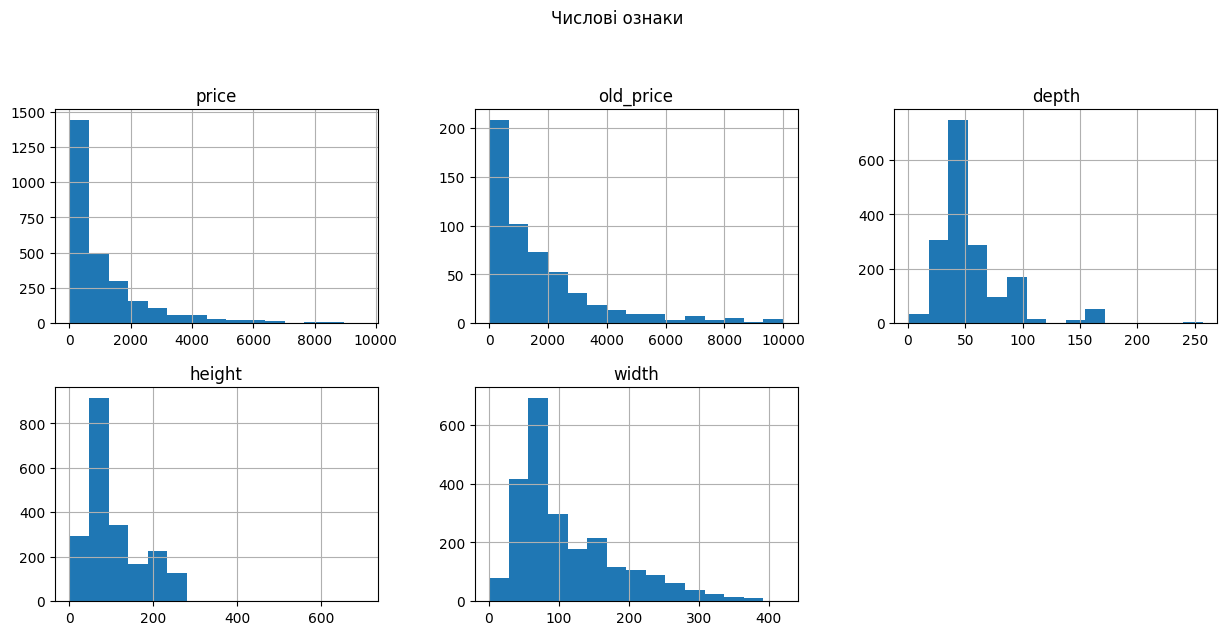

In [19]:
print('\nГрафіки числових ознак:\n', '-'*150)
df_cleaned[numerical_features].hist(bins=15, figsize=(15,10), layout=(3, 3))
plt.suptitle(f'Числові ознаки')
plt.show()


Розподіл малочисленних категоріальних ознак:
 ----------------------------------------------------------------------------------------------------


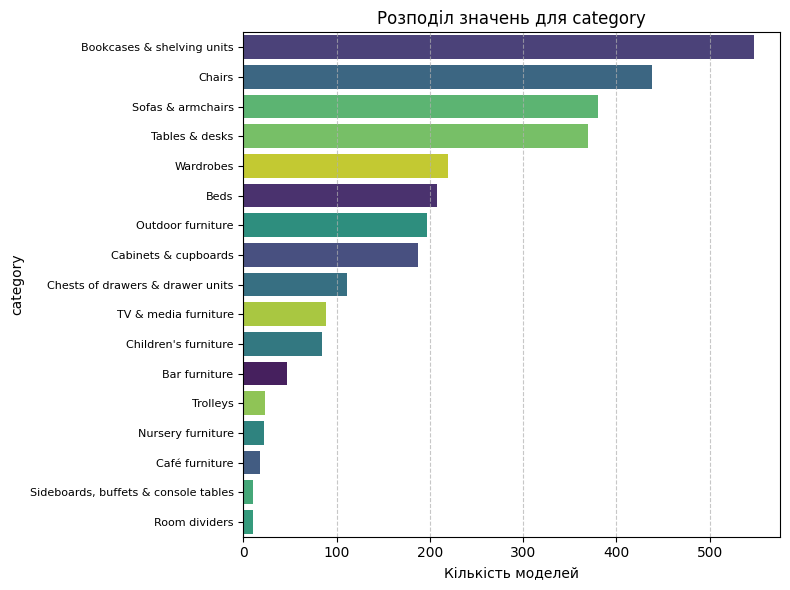

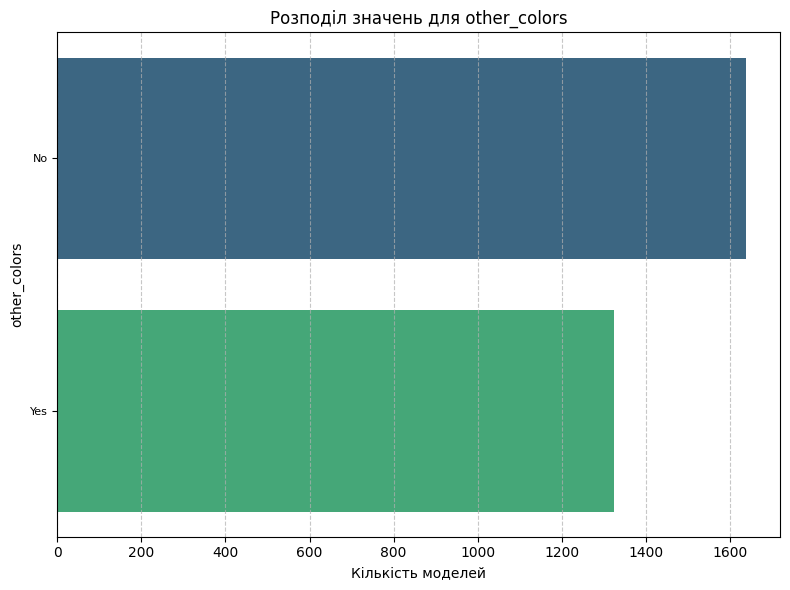

In [20]:
print('\nРозподіл малочисленних категоріальних ознак:\n', '-'*100)

for feature in few_categorical_features:
    plt.figure(figsize=(8, 6))
    order = df[feature].value_counts().index # Порядок категорій за кількістю
    sns.countplot(data=df, y=feature, hue=feature, palette='viridis', order=order)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=8)
    plt.title(f'Розподіл значень для {feature}', fontsize=12)
    plt.ylabel(f'{feature}', fontsize=10)
    plt.xlabel('Кількість моделей', fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Графіки численних категоріальних ознак:
 ----------------------------------------------------------------------------------------------------


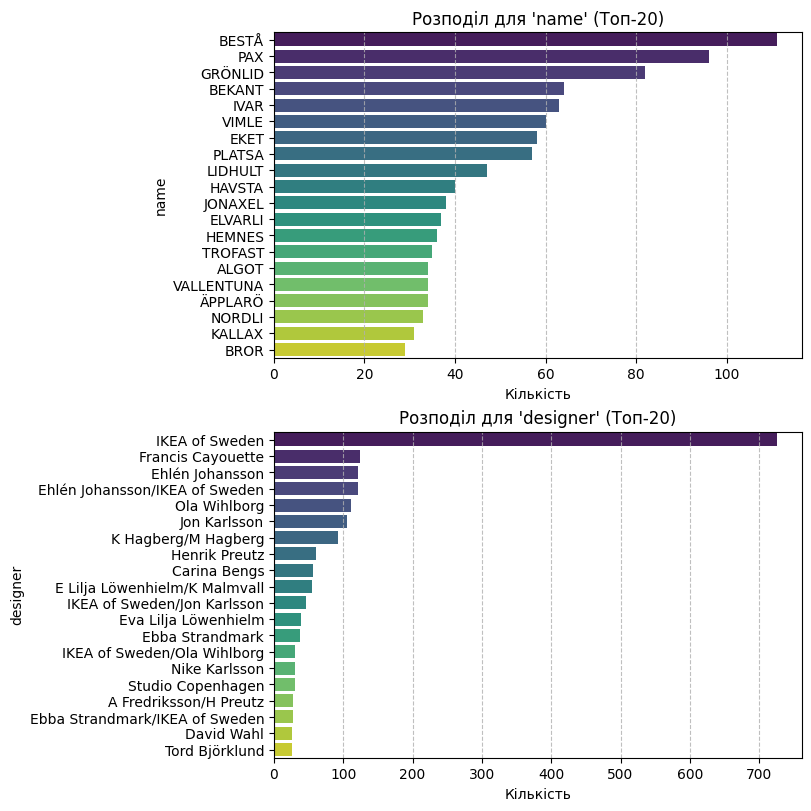

In [21]:
#Для численних категоріальних ознак виводимо топ-20:
print('\nГрафіки численних категоріальних ознак:\n', '-'*100)
num_features = len(alot_categorical_features)
fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(8, 4 * num_features), constrained_layout=True)

for ax, feature in zip(axes, alot_categorical_features):
    value_counts = df_cleaned[feature].value_counts().head(20)
    sns.barplot(x=value_counts.values, y=value_counts.index, ax=ax, palette='viridis')
    ax.set_title(f"Розподіл для '{feature}' (Топ-20)", fontsize=12)
    ax.set_xlabel("Кількість", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.8)

plt.show()

*   Аналіз викидів для числових ознак(['price']):

In [22]:
#a.Метод Z-оцінки (Z-score):
df_cleaned.loc[:, 'z_score_price'] = zscore(df_cleaned['price'])
df_price_outliers = df_cleaned[df_cleaned['z_score_price'].abs() > 3]
print(f'Кількість цін, які є статистичними викидами (на основі Z-оцінки): {df_price_outliers.shape[0]}')

Кількість цін, які є статистичними викидами (на основі Z-оцінки): 69


<ipython-input-22-a78c2613269f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'z_score_price'] = zscore(df_cleaned['price'])


In [23]:
#b.Метод IQR (міжквартильний розмах):
Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df_cleaned[(df_cleaned['price'] < lower_bound) | (df_cleaned['price'] > upper_bound)]
print(f'Кількість цін, які є статистичними викидами (на основі IQR-оцінки): {df_outliers.shape[0]}')

Кількість цін, які є статистичними викидами (на основі IQR-оцінки): 199


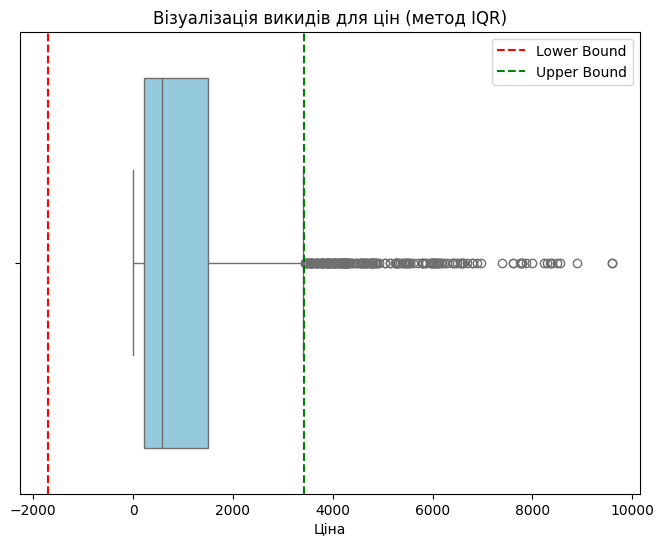

In [24]:
# Візуалізація викидів для цін на основі IQR-оцінки:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_cleaned, x='price', color='skyblue')
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.title('Візуалізація викидів для цін (метод IQR)', fontsize=12)
plt.xlabel('Ціна', fontsize=10)
plt.legend()
plt.show()

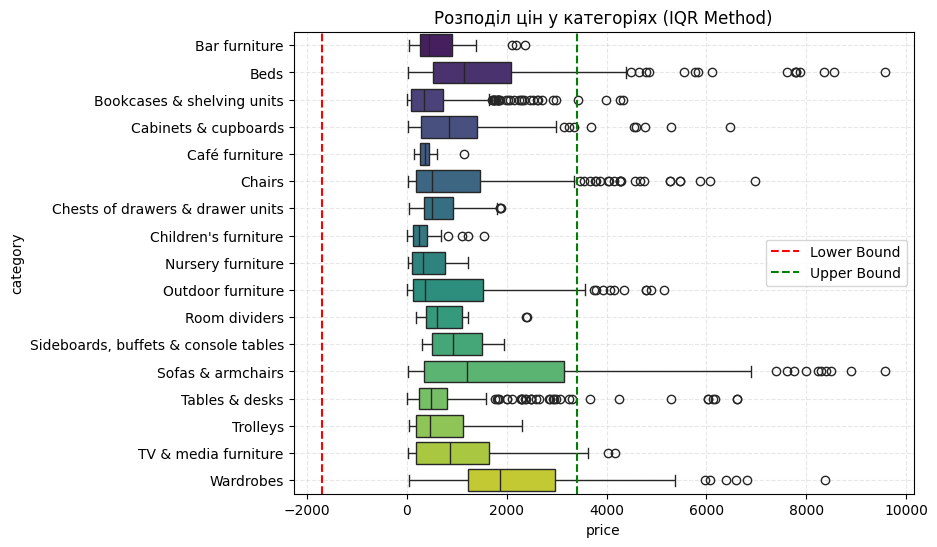

In [25]:
# Візуалізація викидів цін для різних категорій на основі IQR-оцінки:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_cleaned, y='category', x='price', palette='viridis')
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.title('Розподіл цін у категоріях (IQR Method)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.yticks
plt.legend()
plt.show()

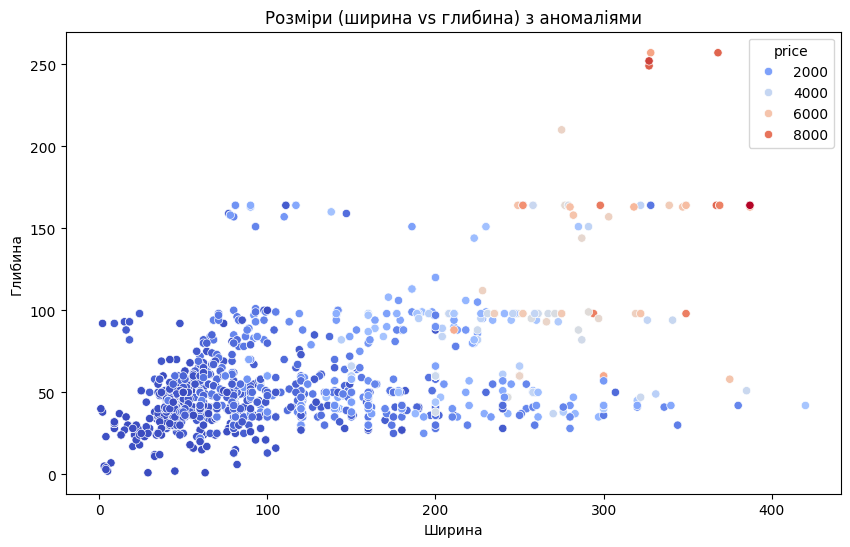

In [26]:
#Залежність ціни (відтінок кольору) від ширини і глибини з розподілом аномалій:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='width', y='depth', hue='price', palette='coolwarm')
plt.title('Розміри (ширина vs глибина) з аномаліями')
plt.xlabel('Ширина')
plt.ylabel('Глибина')
plt.show()

*   Аналіз категоріальнихих ознак:

In [27]:
#Центральне значення ціни для малочисленних категоріальних ознак:
for feature in few_categorical_features:
    print('-' * 100)
    print(f'Медіана ціни для: {df_cleaned.groupby(feature)["price"].median()}')
    print('-' * 100)

----------------------------------------------------------------------------------------------------
Медіана ціни для: category
Bar furniture                            445.0
Beds                                    1145.0
Bookcases & shelving units               337.5
Cabinets & cupboards                     845.0
Café furniture                           370.0
Chairs                                   499.0
Chests of drawers & drawer units         499.0
Children's furniture                     242.5
Nursery furniture                        322.5
Outdoor furniture                        356.0
Room dividers                            595.0
Sideboards, buffets & console tables     927.5
Sofas & armchairs                       1195.5
TV & media furniture                     860.0
Tables & desks                           475.0
Trolleys                                 468.5
Wardrobes                               1870.0
Name: price, dtype: float64
---------------------------------------------

# ***Описова статистика***

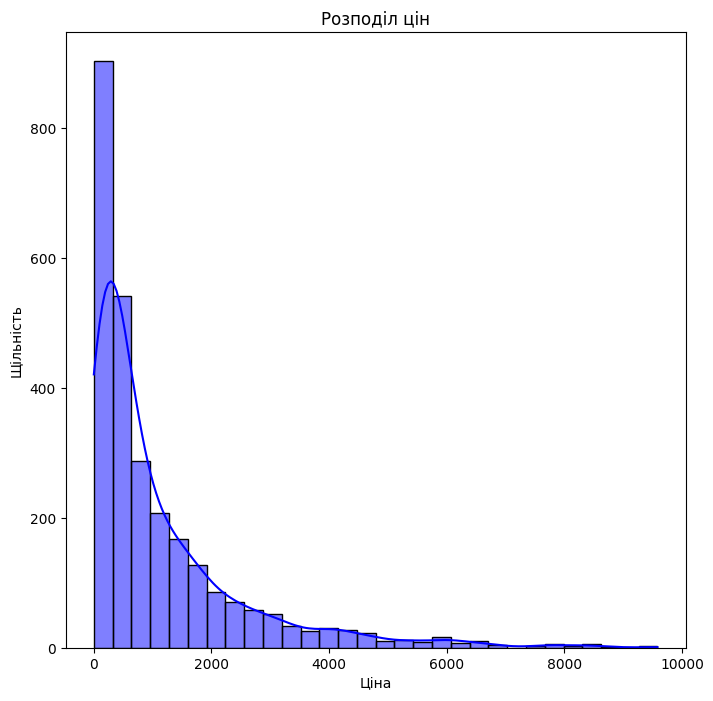

In [28]:
#Оцінка ядерної щільності (KDE) для ['price']:
plt.figure(figsize=(8, 8))
sns.histplot(df_cleaned['price'], bins=30, kde=True, color='blue')
plt.title('Розподіл цін')
plt.xlabel('Ціна')
plt.ylabel('Щільність')
plt.show()

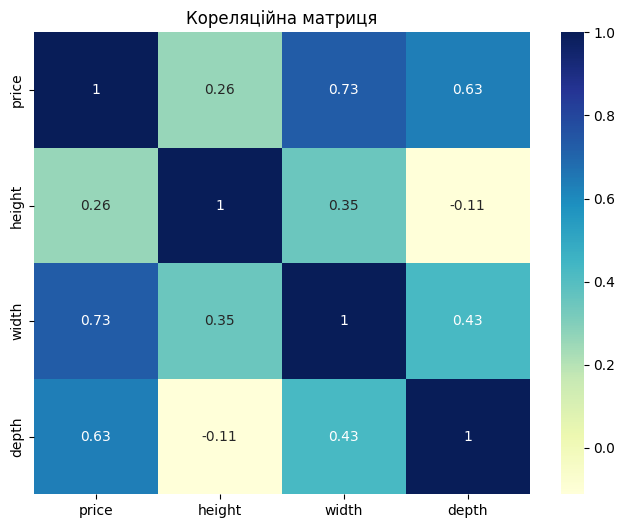

In [29]:
#Кореляція між числовими змінними
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[['price', 'height', 'width', 'depth']].corr(), annot=True, cmap='YlGnBu')
plt.title('Кореляційна матриця')
plt.show()

In [30]:
# Оцінка пропущених значень:
print(df_cleaned.isnull().sum())

item_id               0
name                  0
category              0
price                 0
old_price          2186
sellable_online       0
other_colors          0
designer              0
depth               996
height              646
width               391
z_score_price         0
dtype: int64


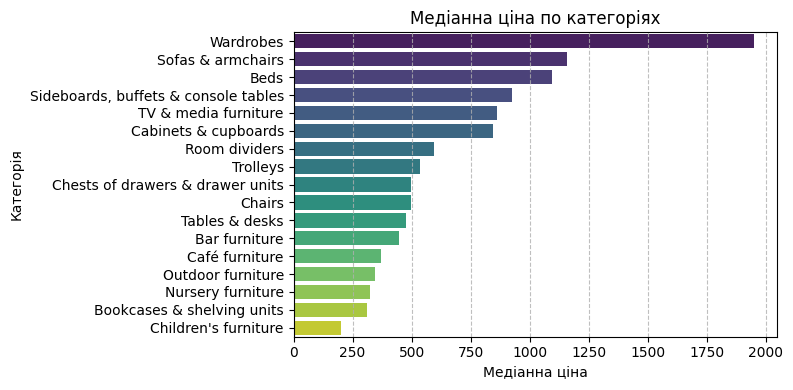

In [31]:
#Медіанна ціна по категоріях:
category_price_median = df.groupby('category')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(y=category_price_median.index, x=category_price_median.values, palette='viridis', orient='h')
plt.title('Медіанна ціна по категоріях', fontsize=12)
plt.xlabel('Медіанна ціна', fontsize=10)
plt.ylabel('Категорія', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()


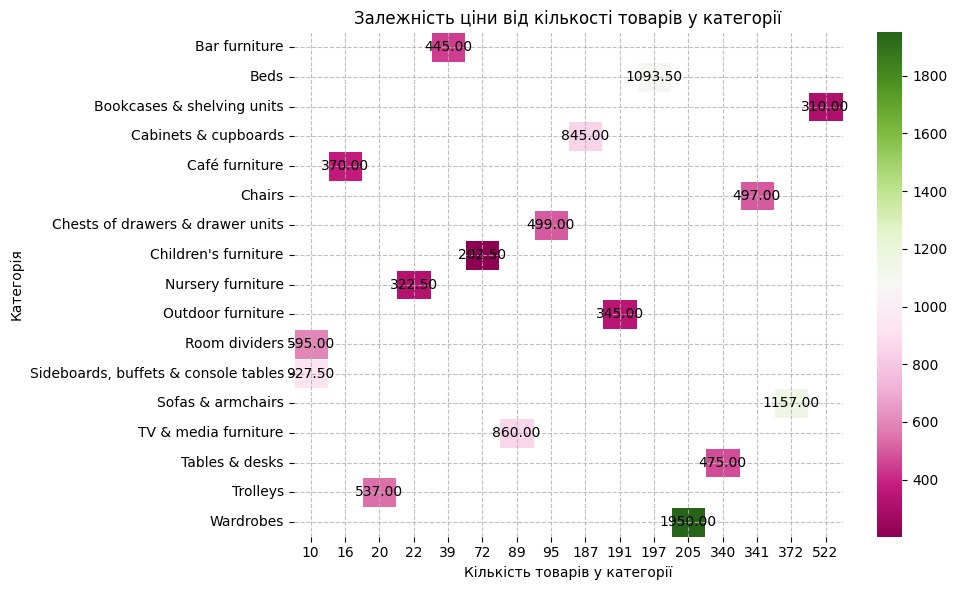

In [32]:
#Залежність між центральною ціною та кількістю товарів у категорії:
category_counts = df_cleaned['category'].value_counts()
category_summary = pd.DataFrame({'category_counts': category_counts, 'category_price_median': category_price_median})# Об'єднання центральної ціни та кількості товарів в одну таблицю

plt.figure(figsize=(10, 6))
pivot_data = category_summary.pivot_table(index='category', values='category_price_median', columns='category_counts')
sns.heatmap(pivot_data, annot=True, cmap='PiYG', cbar=True, fmt='.2f', annot_kws={'size': 10, 'color': 'black'}, linewidths=0.5)
plt.title('Залежність ціни від кількості товарів у категорії', fontsize=12)
plt.xlabel('Кількість товарів у категорії', fontsize=10)
plt.ylabel('Категорія', fontsize=10)
plt.grid(True,linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

In [33]:
# Кількість товарів в одному кольорі та з альтернативними кольорами по категоріях:
categories_in_one_color = df_cleaned[df_cleaned['other_colors'] == 'No']
categories_in_one_color_count = categories_in_one_color['category'].value_counts()
categories_with_other_colors = df_cleaned[df_cleaned['other_colors'] == 'Yes']
categories_with_other_colors_count = categories_with_other_colors['category'].value_counts()

categories_summary = pd.DataFrame({
    'One Color': categories_in_one_color_count,
    'Dif Colors': categories_with_other_colors_count
}).fillna(0).astype(int)

categories_summary['Total'] = categories_summary['One Color'] + categories_summary['Dif Colors']
categories_summary = categories_summary.sort_values('Total', ascending=False)
print(categories_summary)

                                      One Color  Dif Colors  Total
category                                                          
Bookcases & shelving units                  294         228    522
Sofas & armchairs                            57         315    372
Chairs                                      253          88    341
Tables & desks                              197         143    340
Wardrobes                                   166          39    205
Beds                                        104          93    197
Outdoor furniture                           115          76    191
Cabinets & cupboards                         47         140    187
Chests of drawers & drawer units             47          48     95
TV & media furniture                         24          65     89
Children's furniture                         44          28     72
Bar furniture                                34           5     39
Nursery furniture                            15           7   

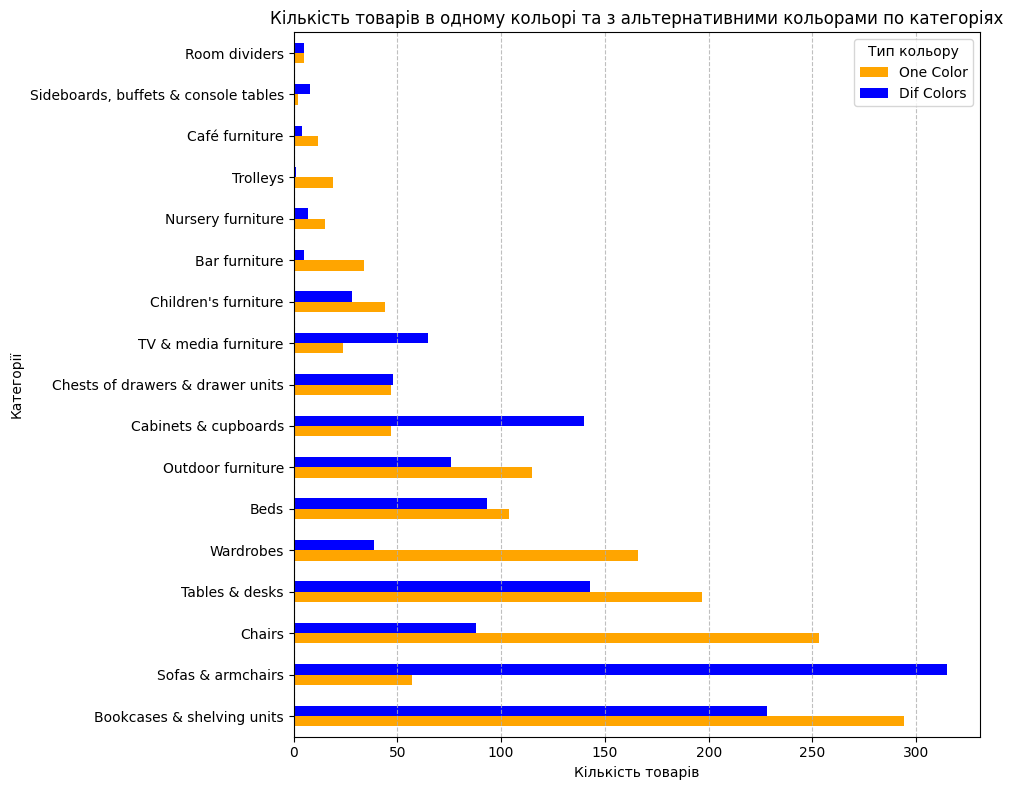

In [34]:
#Візуалізація
categories_summary[['One Color', 'Dif Colors']].plot(
    kind='barh', figsize=(10, 8), color=['orange', 'blue']
)
plt.title('Кількість товарів в одному кольорі та з альтернативними кольорами по категоріях', fontsize=12)
plt.xlabel('Кількість товарів', fontsize=10)
plt.ylabel('Категорії', fontsize=10)
plt.legend(title='Тип кольору')
plt.grid(axis='x',linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

In [35]:
# Заповнення NaN у `old_price`
df_cleaned.loc[:, 'price_ratio'] = df_cleaned['old_price'] / df_cleaned['price']# Розрахунок співвідношення
avg_ratio = df_cleaned['price_ratio'].median()# Обчислення медіани
df_cleaned.loc[:, 'old_price'] = df_cleaned['old_price'].fillna(df_cleaned['price'] * avg_ratio)# Заповнення пропущених значень

<ipython-input-35-f41218af88f7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'price_ratio'] = df_cleaned['old_price'] / df_cleaned['price']# Розрахунок співвідношення


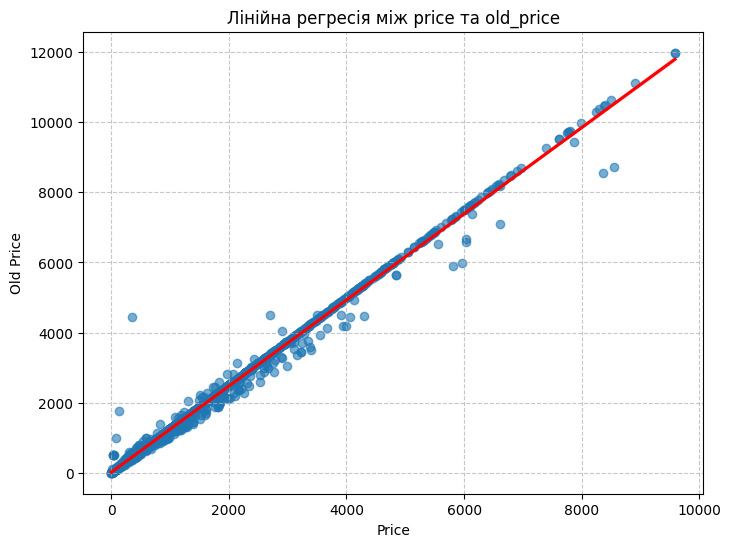

In [36]:
#Лінійна регресія між price та old_price:
plt.figure(figsize=(8, 6))
sns.regplot(x='price', y='old_price', data=df_cleaned, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.title('Лінійна регресія між price та old_price', fontsize=12)
plt.xlabel('Price', fontsize=10)
plt.ylabel('Old Price', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

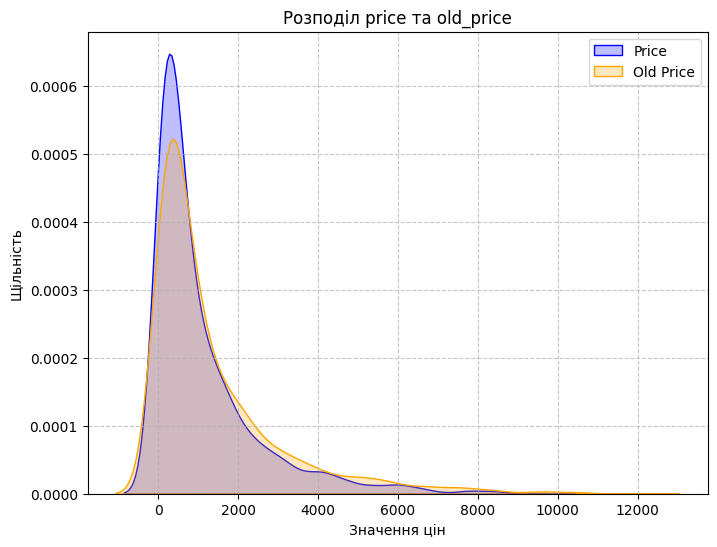

In [37]:
#Крива розподілу між price та old_price
plt.figure(figsize=(8, 6))
sns.kdeplot(df_cleaned['price'], label='Price', shade=True, color='blue')
sns.kdeplot(df_cleaned['old_price'], label='Old Price', shade=True, color='orange')
plt.title('Розподіл price та old_price', fontsize=12)
plt.xlabel('Значення цін', fontsize=10)
plt.ylabel('Щільність', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [38]:
# Підрахунок товарів, що продаються та не продаються онлайн:
sellable_count = df_cleaned['sellable_online'].value_counts()
print(f"Кількість товарів, що продаються онлайн: {sellable_count.get(True, 0)}")
print(f"Кількість товарів, що не продаються онлайн: {sellable_count.get(False, 0)}\n" + '-' * 60)

Кількість товарів, що продаються онлайн: 2710
Кількість товарів, що не продаються онлайн: 18
------------------------------------------------------------


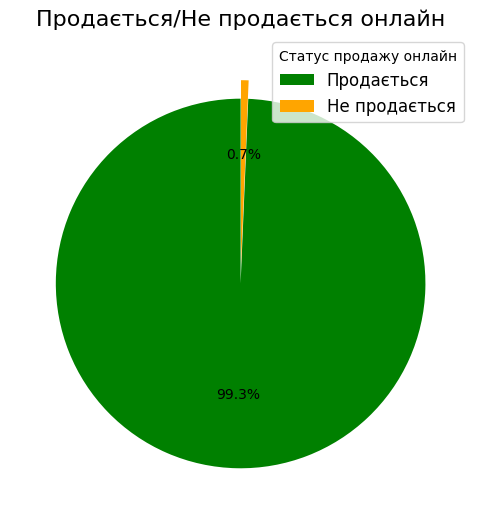

In [39]:
#Кругова діаграма товарів, що продаються та не продаються онлайн:
online_counts = df_cleaned['sellable_online'].value_counts()# К-сть товарів True/False
labels = [ 'Продається','Не продається']
colors = ['green','orange']
plt.figure(figsize=(8, 6))
patches, texts, autotexts = plt.pie(
    online_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.1, 0]  # Зміщення для "Не продається"
)
plt.legend(patches, labels, loc="best", fontsize=12, title="Статус продажу онлайн")#легенда
plt.title('Продається/Не продається онлайн', fontsize=16)
plt.show()

In [40]:
# Розподіл товарів, що продаються та не продаються онлайн по категоріях:
not_sellable_online = df_cleaned[df_cleaned['sellable_online'] == False]
categories_not_sellable_online = not_sellable_online['category'].value_counts()
sellable_online = df[df['sellable_online'] == True]
categories_sellable_online = sellable_online['category'].value_counts()

categories_summary = pd.DataFrame({
    'Not Sellable Online': categories_not_sellable_online,
    'Sellable Online': categories_sellable_online
}).fillna(0)  # Міняємо NaN на 0
categories_summary['Total'] = categories_summary['Not Sellable Online'] + categories_summary['Sellable Online']
#Приводимо до єдиного типу даних:
categories_summary['Not Sellable Online'] = categories_summary['Not Sellable Online'].astype(int)
categories_summary['Total'] = categories_summary['Total'].astype(int)

print(categories_summary.to_string())

                                      Not Sellable Online  Sellable Online  Total
category                                                                         
Bar furniture                                           3               44     47
Beds                                                    3              205    208
Bookcases & shelving units                              1              547    548
Cabinets & cupboards                                    0              187    187
Café furniture                                          0               18     18
Chairs                                                  3              435    438
Chests of drawers & drawer units                        0              111    111
Children's furniture                                    4               79     83
Nursery furniture                                       1               21     22
Outdoor furniture                                       0              197    197
Room dividers   

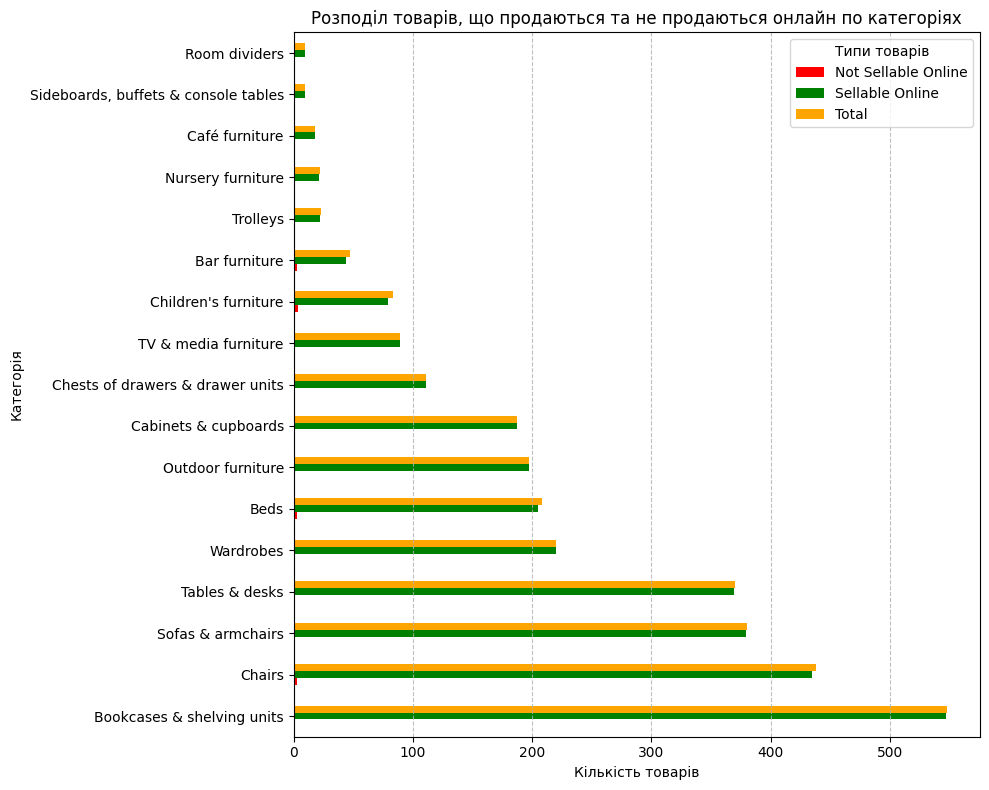

In [41]:
# Візуалізація розподілу товарів, що продаються та не продаються онлайн по категоріях:
categories_summary.sort_values('Total', ascending=False).plot(
    kind='barh', figsize=(10, 8), color=['red', 'green', 'orange']
)
plt.title('Розподіл товарів, що продаються та не продаються онлайн по категоріях', fontsize=12)
plt.ylabel('Категорія', fontsize=10)
plt.xlabel('Кількість товарів', fontsize=10)
plt.legend(title='Типи товарів')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

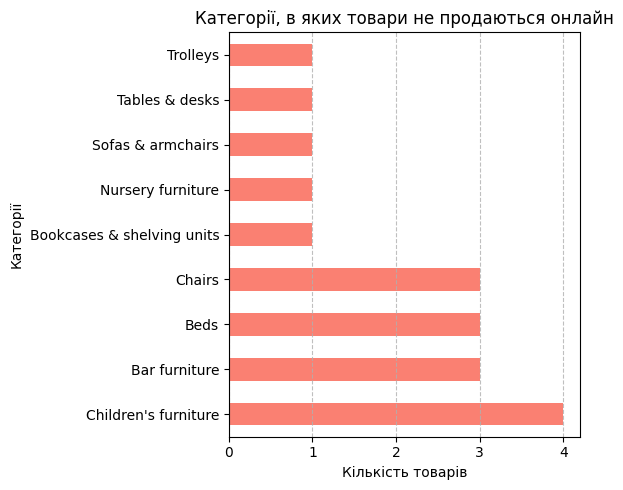

In [42]:
# Категорії, де товари не продаються онлайн:
plt.figure(figsize=(6, 5))
categories_not_sellable_online.plot(kind='barh', color='salmon')
plt.title('Категорії, в яких товари не продаються онлайн', fontsize=12)
plt.ylabel('Категорії', fontsize=10)
plt.xlabel('Кількість товарів', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

In [43]:
# Колонка ['name'](моделі):
df_cleaned['name'].describe()

,name
count,2728
unique,607
top,BESTÅ
freq,111


In [44]:
#Кількість моделей в лінійці товарів з однаковим ім'ям:
item_per_name = df_cleaned.groupby('name')['item_id'].count()
summary_table = item_per_name.to_frame('item_count').sort_values(by='item_count', ascending=False)
print(summary_table)

                   item_count
name                         
BESTÅ                     111
PAX                        96
GRÖNLID                    82
BEKANT                     64
IVAR                       63
...                       ...
KROKHOLMEN                  1
KRITTER                     1
KRILLE                      1
KOPPANG                     1
ÖVRARYD / JANINGE           1

[607 rows x 1 columns]


In [45]:
#Діапазон цін в лінійці товарів з однаковим ім'ям:
item_count_per_name = df_cleaned.groupby('name')['item_id'].count()
min_max_per_name = df_cleaned.groupby('name')['price'].agg(min_price=('min'), max_price=('max'))#Знаходимо мінімальну та максимальну ціни для кожної лінійки товарів
summary_table = item_count_per_name.to_frame('item_count').join(min_max_per_name)
summary_table_sorted = summary_table.sort_values(by='item_count', ascending=False)
print(summary_table_sorted.head(50))

                 item_count  min_price  max_price
name                                             
BESTÅ                   111       15.0     4260.0
PAX                      96      530.0     8380.0
GRÖNLID                  82       60.0     8900.0
BEKANT                   64       49.0     6614.0
IVAR                     63       25.0     2275.0
VIMLE                    60       50.0     8395.0
EKET                     58       12.0     2020.0
PLATSA                   57      307.0     3493.0
LIDHULT                  47      100.0     9585.0
HAVSTA                   40       80.0     4770.0
JONAXEL                  38       15.0      990.0
ELVARLI                  37      434.0     4128.0
HEMNES                   36       70.0     3986.0
TROFAST                  35        5.0      475.0
VALLENTUNA               34       40.0     7988.0
ALGOT                    34        6.0      594.0
ÄPPLARÖ                  34       99.0     4145.0
NORDLI                   33      140.0     2290.0


In [46]:
unique_designers = df_cleaned['designer'].unique()# Вивід унікальних значень
print(f'Кількість унікальних дизайнерів: {len(unique_designers)}\n', '-'*70)
print(unique_designers)

Кількість унікальних дизайнерів: 199
 ----------------------------------------------------------------------
['Nicholai Wiig Hansen' 'Francis Cayouette' 'Henrik Preutz'
 'Marcus Arvonen' 'Carina Bengs' 'K Hagberg/M Hagberg' 'Sarah Fager'
 'Ehlén Johansson' 'Nike Karlsson' 'Maja Ganszyniec' 'Karl Malmvall'
 'Caroline/John/Jonas/Paul/Petrus' 'Maja Ganszyniec/Nike Karlsson'
 'J Karlsson/N Karlsson' 'IKEA of Sweden/Karl Malmvall' 'IKEA of Sweden'
 'J Karlsson/N Karlsson/Nike Karlsson' 'Ola Wihlborg'
 'IKEA of Sweden/Tina Christensen' 'IKEA of Sweden/K Hagberg/M Hagberg'
 'IKEA of Sweden/Ola Wihlborg' 'Ebba Strandmark/IKEA of Sweden'
 'Jon Karlsson' 'Carina Bengs/IKEA of Sweden' 'David Wahl'
 'IKEA of Sweden/Jon Karlsson' 'IKEA of Sweden/Paulin Machado'
 'Eva Lilja Löwenhielm/IKEA of Sweden'
 'IKEA of Sweden/Ola Wihlborg/Synnöve Mork' 'David Wahl/IKEA of Sweden'
 'Eva Lilja Löwenhielm' 'Anna Efverlund/IKEA of Sweden' 'Paulin Machado'
 'Jonas Hultqvist' 'Gustav Carlberg' 'Carl Öjerstam' 'Vir

In [47]:
#Кількість моделей, спроектованих кожним із дизайнерів чи групою дизайнерів:
designer_counts = df_cleaned.groupby('designer')['item_id'].nunique().reset_index()
designer_counts.columns = ['Designer', 'Product Count']
designer_counts = designer_counts.sort_values(by='Product Count', ascending=False)
print(designer_counts)

                                     Designer  Product Count
103                            IKEA of Sweden            725
79                          Francis Cayouette            124
62             Ehlén Johansson/IKEA of Sweden            122
57                            Ehlén Johansson            122
185                              Ola Wihlborg            111
..                                        ...            ...
126               IKEA of Sweden/Virgil Abloh              1
40                Chris Martin/IKEA of Sweden              1
41   Chris Martin/IKEA of Sweden/Mia Lagerman              1
121             IKEA of Sweden/Paulin Machado              1
139     J Löfgren/J Pettersson/Marcus Arvonen              1

[199 rows x 2 columns]


In [48]:
designer_counts = df_cleaned.groupby('designer')['item_id'].nunique().reset_index()
designer_counts.columns = ['Designer', 'Product Count']
designer_counts = designer_counts.sort_values(by='Product Count', ascending=False).head(50)

print(designer_counts)

                                             Designer  Product Count
103                                    IKEA of Sweden            725
79                                  Francis Cayouette            124
62                     Ehlén Johansson/IKEA of Sweden            122
57                                    Ehlén Johansson            122
185                                      Ola Wihlborg            111
149                                      Jon Karlsson            105
152                               K Hagberg/M Hagberg             93
100                                     Henrik Preutz             61
18                                       Carina Bengs             56
50                      E Lilja Löwenhielm/K Malmvall             55
107                       IKEA of Sweden/Jon Karlsson             46
71                               Eva Lilja Löwenhielm             39
53                                    Ebba Strandmark             37
183                               

# ***Гіпотези та їх перевірка:***


:
 **1. Гіпотеза 1: Товари з більшою кількістю кольорових варіантів коштують дорожче**

*   Тест 1: Кореляційний аналіз

In [49]:
stat, p = shapiro(df_cleaned['price'])
print(f"P-value: {p}")

P-value: 7.017723255676675e-55


тест Шапіро-Вілка:
P-value: 7.017723255676675e-55 (дуже мале значення) вказує, що дані в колонці 'price' значно відрізняються від нормального розподілу.

In [50]:
#Зв'язок між наявністю альтернативних кольорів і ціною товару з використанням коефіцієнта Спірмена:
df_cleaned.loc[:, 'color_count'] = df_cleaned['other_colors'].map({'No': 0, 'Yes': 1})
corr, p_value = spearmanr(df_cleaned['color_count'], df_cleaned['price'])
print(f"Spearman Correlation: {corr}, p-value: {p_value}")

Spearman Correlation: 0.12504445891830168, p-value: 5.6072640137641496e-11


<ipython-input-50-e295b5385f16>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'color_count'] = df_cleaned['other_colors'].map({'No': 0, 'Yes': 1})


Кореляція Спірмена (ρ = 0.125):
існує слабкий позитивний зв'язкок між наявністю альтернативних кольорів у товара та його ціною.Товари з додатковими кольорами можуть мати дещо вищу ціну, але цей зв'язок є дуже слабким.

p-value (5.6e-11) :
значення дуже мале, набагато менше за стандартний рівень значущості 0.05. Це означає, що спостережуваний зв'язок статистично значущий, і хоча зв'язок слабкий, він не є випадковим.

*   Тест 2:  Груповий аналіз середніх

In [51]:
#Середнє значення ціни для товарів, що мають/не мають альтернативні кольори:
price_by_color = df_cleaned.groupby('other_colors')['price'].mean()
print(price_by_color)

other_colors
No      970.692962
Yes    1284.345553
Name: price, dtype: float64


In [52]:
# Виконуємо t-тест
yes_group = df_cleaned[df_cleaned['other_colors'] == 'Yes']['price']
no_group = df_cleaned[df['other_colors'] == 'No']['price']

stat, p_value = ttest_ind(yes_group, no_group)

if p_value < 0.05:
    print("Для товарів, що мають альтернативні кольори, та для товарів в одному кольорі є статистично значущі відмінності між середніми цінами.")
else:
    print("Для товарів, що мають альтернативні кольори, та для товарів в одному кольорі немає статистично значущих відмінностей між середніми цінами.")

print(f"P-value: {p_value:.5f}")

Для товарів, що мають альтернативні кольори, та для товарів в одному кольорі є статистично значущі відмінності між середніми цінами.
P-value: 0.00000


Згідно незалежного t-тесту та групового аналізу середніх, наявність додаткових кольорів (або їх відсутність) може впливати на ціну товарів.

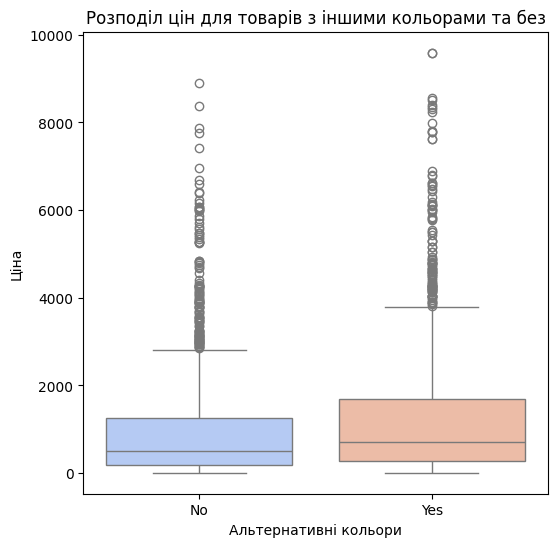

In [53]:
# Візуалізація розподілу цін по категоріях
plt.figure(figsize=(6, 6))
sns.boxplot(x='other_colors', y='price', data=df_cleaned, palette='coolwarm')
plt.title('Розподіл цін для товарів з іншими кольорами та без', fontsize=12)
plt.xlabel('Альтернативні кольори')
plt.ylabel('Ціна')
plt.show()

**2.  Гіпотеза 2: Товари однієї категорії мають схожу цінову політику.**
*   Тест 1: Дисперсійний аналіз

In [54]:
anova_result = f_oneway(*[group['price'] for _, group in df_cleaned.groupby('category')])
print(f"ANOVA p-value: {anova_result.pvalue}")

ANOVA p-value: 1.1081656813801085e-98


Дисперсійний аналіз: отриманий p-value для тесту ANOVA (1.1081656813801085e-98) є дуже малим і вказує на те, що різниця між групами є значущою.

*   Тест 2: Коефіцієнт варіації



In [55]:
# Розрахунок коефіцієнта варіації для кожної категорії:
cv_by_category = df_cleaned.groupby('category')['price'].agg(['mean', 'std'])

cv_by_category['cv'] = (cv_by_category['std'] / cv_by_category['mean']) * 100
print(cv_by_category)

                                             mean          std          cv
category                                                                  
Bar furniture                          674.564103   590.692136   87.566494
Beds                                  1696.177665  1843.290975  108.673225
Bookcases & shelving units             532.381226   637.178624  119.684653
Cabinets & cupboards                  1044.823529  1042.193571   99.748287
Café furniture                         391.625000   233.194590   59.545379
Chairs                                1037.896188  1268.980136  122.264650
Chests of drawers & drawer units       645.121053   447.534450   69.372166
Children's furniture                   292.819444   276.582226   94.454870
Nursery furniture                      431.772727   355.908219   82.429527
Outdoor furniture                      942.914136  1212.508895  128.591655
Room dividers                          912.600000   832.770236   91.252491
Sideboards, buffets & con

  Категорії "Tables & desks " та "Outdoor furniture"
мають високий коефіцієнт варіації (132.3 та 128.6 ) , що свідчить про значну варіативність цін. Це може означати широкий асортимент товарів з різними характеристиками, які мають значні відмінності в цінах.

---


Категорії "Sideboards, buffets & console tables" та "Café furniture " мають менший коефіцієнт варіації  (58.03 та  59.5), що вказує на більш стабільні ціни всередині цих категорій.

---


Деякі категорії, як "Sofas & armchairs", мають високе стандартне відхилення (2083.5), що означає значний діапазон цін, тоді як інші категорії, як "Sideboards, buffets & console tables", мають менше стандартне відхилення (587.8), що вказує на більш зосереджений діапазон цін.

*   Тест 3: Кластеризація

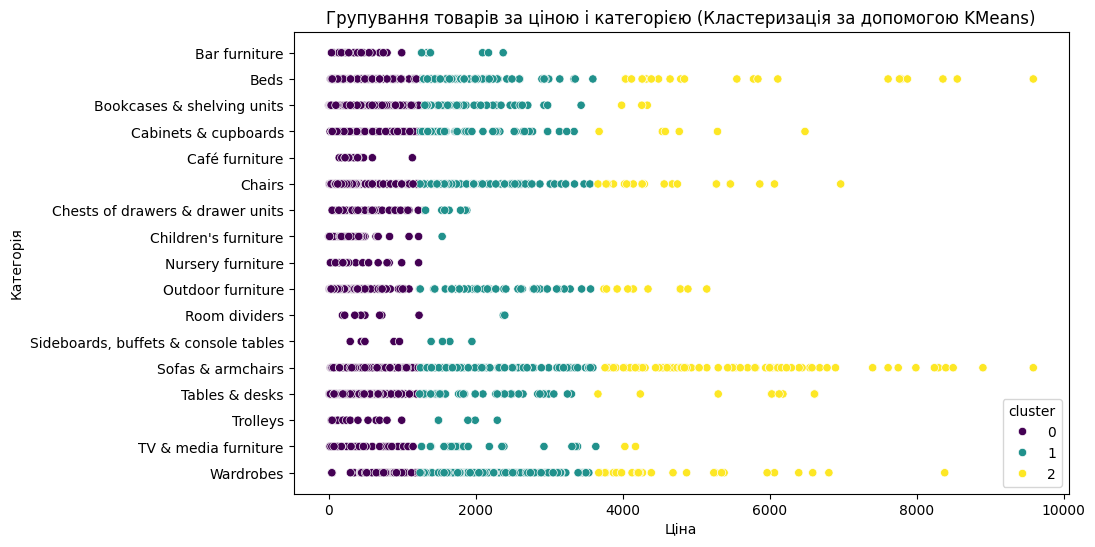

In [56]:
# Вибір необхідних стовпців і створення копії DataFrame
df_category = df_cleaned[['price', 'category']].copy()

# Стандартизація стовпця 'price'
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_category[['price']])

kmeans = KMeans(n_clusters=3, random_state=42)# Кластеризація за допомогою KMeans

df_category.loc[:, 'cluster'] = kmeans.fit_predict(scaled_data)# Навчаємо модель

centroids = kmeans.cluster_centers_# Додаємо інформацію про центри кластерів

# Візуалізація кластерів за ціною
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_category, x='price', y='category', hue='cluster', palette='viridis')
plt.title('Групування товарів за ціною і категорією (Кластеризація за допомогою KMeans)')
plt.xlabel('Ціна')
plt.ylabel('Категорія')
plt.show()

In [57]:
#Cередні ціни в кожному кластері:
cluster_means = df_category.groupby('cluster')['price'].mean()
print(f'Cередня ціна для {cluster_means}')

Cередня ціна для cluster
0     413.333123
1    2054.946334
2    5214.192308
Name: price, dtype: float64


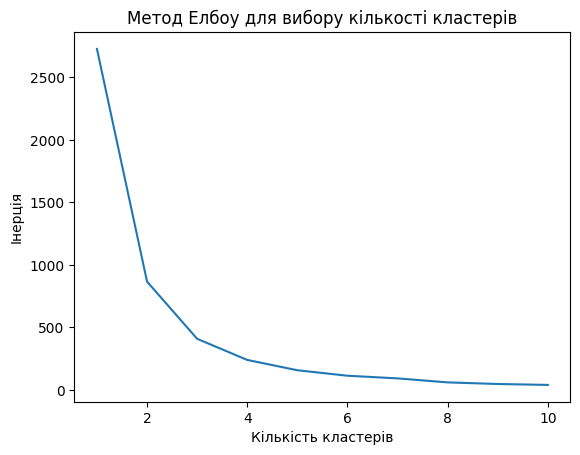

In [58]:
# Метод елбоу для вибору кількості кластерів
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.title('Метод Елбоу для вибору кількості кластерів')
plt.xlabel('Кількість кластерів')
plt.ylabel('Інерція')
plt.show()

*   Тест 3a: Повторна кластеризація (на основі 5 кластерів):

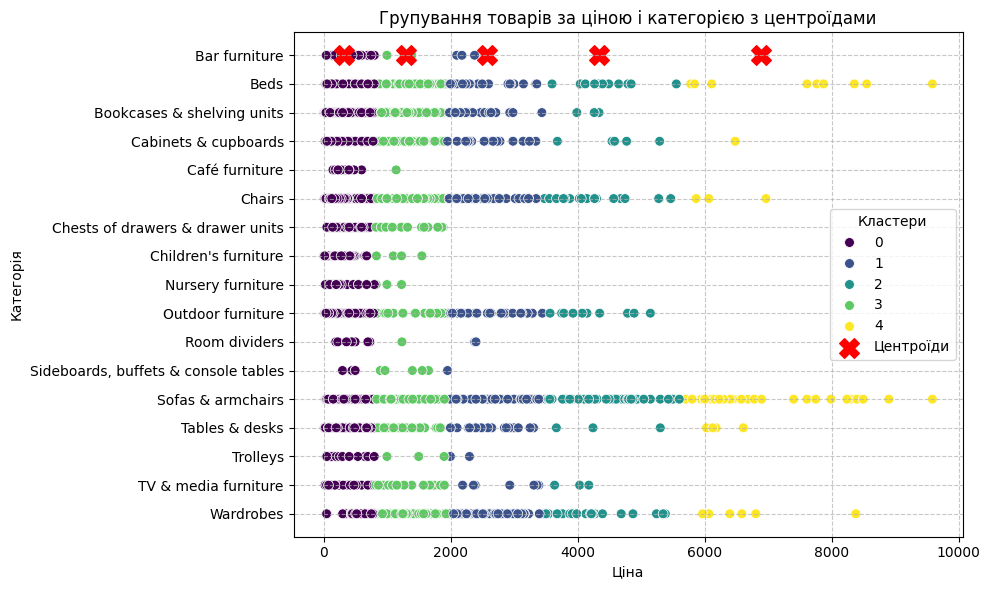

In [59]:
df_category = df_cleaned[['price', 'category']].copy()

# Стандартизація стовпця 'price'
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_category[['price']])

kmeans = KMeans(n_clusters=5, random_state=42)# Кластеризація за допомогою KMeans

df_category.loc[:, 'cluster'] = kmeans.fit_predict(scaled_data)# Навчаємо модель

centroids = kmeans.cluster_centers_# Додаємо інформацію про центри кластерів
centroids_original = scaler.inverse_transform(centroids)  # Зворотнє перетворення масштабування

# Візуалізація кластерів

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_category, x='price', y='category', hue='cluster', palette='viridis', s=50)
plt.scatter(centroids_original[:, 0], [df_category['category'].unique()[0]] * len(centroids_original),
            c='red', s=200, marker='X', label='Центроїди')
plt.title('Групування товарів за ціною і категорією з центроїдами', fontsize=12)
plt.xlabel('Ціна', fontsize=10)
plt.ylabel('Категорія', fontsize=10)
plt.legend(title='Кластери')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Товари в межах однієї категорії розподілені на кілька кластерів  чіткої цінової сегментації.
Гіпотеза, що товари однієї категорії мають схожу цінову політику, знаходить підтвердження в межах кожного кластеру. Проте загальна різниця між цінами в різних кластерах вказує на те, що цінова політика може варіювати навіть серед товарів в одній основній категорії.

# ***Машинне навчання***

**1. Розподіл даних:**

In [60]:
X = df_cleaned[['depth', 'width', 'height', 'category','designer', 'other_colors']]
Y = df_cleaned['price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

**3. Препроцесінг даних з використанням Pipeline:**

In [61]:
# Трансформери для числових та категоріальних даних
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # заповнення пропущених значень медіаною
    ('scaler', StandardScaler())  # масштабування числових даних
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # заповнення пропущених значень найбільш частими
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # перетворення категоріальних змінних в one-hot
])

#Об'єднуємо трансформери, визначаємо числові та категоріальні змінні:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, ['depth', 'width', 'height']),
    ('cat', cat_transformer, ['category', 'designer', 'other_colors'])
])

# Подальше використання
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

**4. Побудова моделей машинного навчання**

In [62]:
# Функція для порівняння моделей
def compare_regression_models(X_train, X_test, Y_train, Y_test, preprocessor):
    models = [
        ('Linear Regression', LinearRegression()),
        ('Lasso Regression', LassoCV(cv=5)),
        ('Ridge Regression', RidgeCV(cv=5)),
        ('Support Vector Regression', SVR(kernel='linear')),
        ('K-Nearest Neighbors', KNeighborsRegressor(n_neighbors=16)),
        ('Decision Tree', DecisionTreeRegressor(max_depth=10, random_state=42)),
        ('Random Forest', RandomForestRegressor(random_state=42)),
        ('Gradient Boosting', GradientBoostingRegressor(random_state=42))
    ]

    results = []

    for name, model in models:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])

        cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='r2')
        pipeline.fit(X_train, Y_train)
        Y_pred = pipeline.predict(X_test)

        mse = mean_squared_error(Y_test, Y_pred)
        rmse = np.sqrt(mse)

        metrics = {
            'Model': name,
            'Test R²': r2_score(Y_test, Y_pred),
            'RMSE': rmse,
            'MSE': mse
        }
        results.append(metrics)

    results_df = pd.DataFrame(results)
    return results_df

In [63]:
results_df = compare_regression_models(X_train, X_test, Y_train, Y_test, preprocessor)
sorted_results_df = results_df.sort_values(by='Test R²', ascending=False)
print(sorted_results_df.to_string(index=False))

                    Model  Test R²        RMSE          MSE
            Random Forest 0.830182  611.028805 3.733562e+05
        Gradient Boosting 0.774825  703.605375 4.950605e+05
            Decision Tree 0.760313  725.924890 5.269669e+05
        Linear Regression 0.740570  755.230297 5.703728e+05
         Ridge Regression 0.730243  770.115666 5.930781e+05
      K-Nearest Neighbors 0.722530  781.047056 6.100345e+05
         Lasso Regression 0.708311  800.810342 6.412972e+05
Support Vector Regression 0.428274 1121.149516 1.256976e+06


In [64]:
# Вибір найкращої моделі на основі Test R²
best_model_name = sorted_results_df.iloc[0]['Model']
best_model_test_r2 = sorted_results_df.iloc[0]['Test R²']

print(f"Найкраща модель: {best_model_name}")
print(f"R² на тестових даних: {best_model_test_r2:.2f}")

Найкраща модель: Random Forest
R² на тестових даних: 0.83


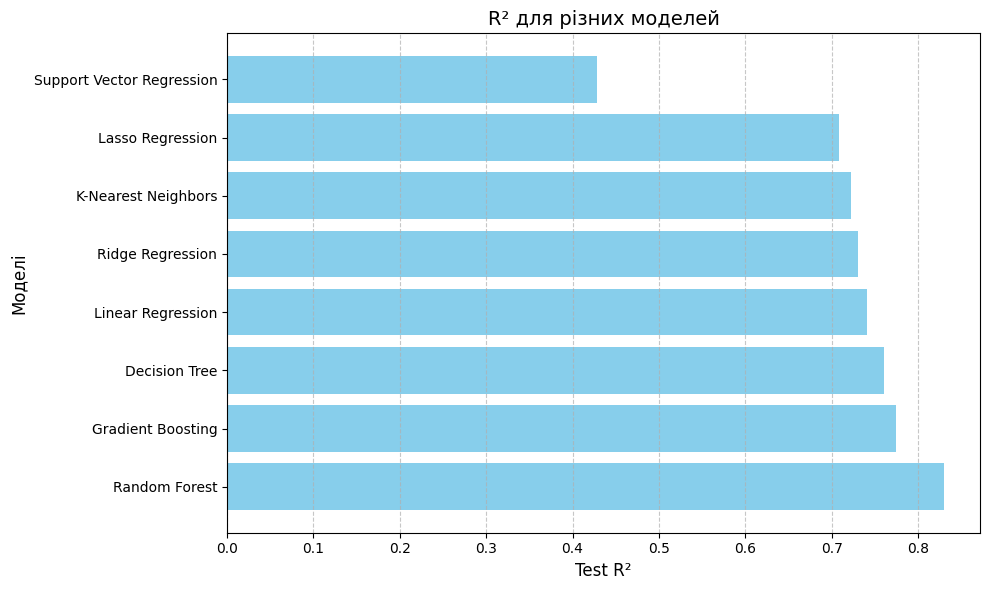

In [65]:
plt.figure(figsize=(10, 6))
heights = sorted_results_df['Test R²']# Висоти стовпців

plt.barh(
    sorted_results_df['Model'],   #мітки по осі Y
    sorted_results_df['Test R²'], #мітки по осі X
    color='skyblue'
)

plt.title('R² для різних моделей', fontsize=14)
plt.xlabel('Test R²', fontsize=12)
plt.ylabel('Моделі', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**5a. GridSearchCV для:**


*    DecisionTreeRegressor:




In [66]:
#Налаштування гіперпараметрів для моделі з допомогою GridSearchCV:

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Налаштування гіперпараметрів для DecisionTreeRegressor
param_grid = {
    'regressor__max_depth': [10, 20, 30, 40, 50],  # Максимальна глибина дерева
    'regressor__min_samples_split': [2, 5, 10],  # Мінімальна кількість зразків для поділу вузла
    'regressor__min_samples_leaf': [1, 2, 4],  # Мінімальна кількість зразків у листі
    'regressor__max_features': ['sqrt', 'log2', None],  # Кількість ознак для поділу
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error']  # Критерій поділу
}

# Виконання GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [67]:
grid_search.fit(X_train, Y_train)
print("Найкращі параметри:", grid_search.best_params_)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Найкращі параметри: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 50, 'regressor__max_features': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}


Feature Names: 204, Feature Importances: 204
                                          Ознака  Важливість (%)
1                                     num__width       42.435223
0                                     num__depth       17.373987
2                                    num__height       11.338940
114                 cat__designer_IKEA of Sweden        2.011550
5       cat__category_Bookcases & shelving units        1.942870
8                           cat__category_Chairs        1.934389
203                        cat__other_colors_Yes        1.163764
66   cat__designer_E Lilja Löwenhielm/K Malmvall        1.081915
202                         cat__other_colors_No        1.077072
15               cat__category_Sofas & armchairs        0.752584


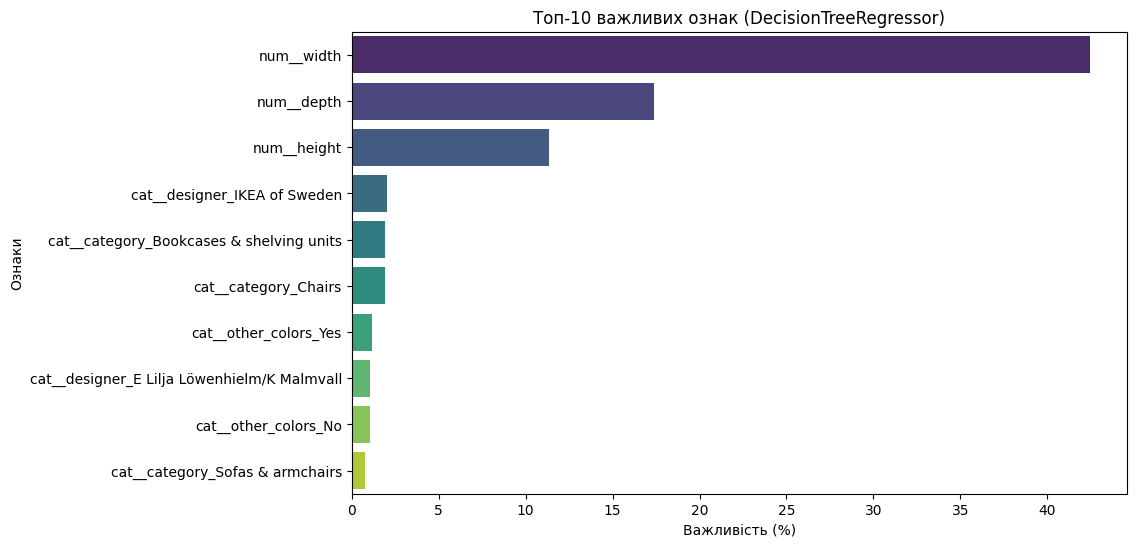

In [68]:
# Отримуємо імена ознак після трансформації
feature_names = preprocessor.get_feature_names_out()

# Отримуємо важливість ознак у відсотках
feature_importances = grid_search.best_estimator_.named_steps['regressor'].feature_importances_

# Перевіряємо довжини
print(f"Feature Names: {len(feature_names)}, Feature Importances: {len(feature_importances)}")

# Створюємо DataFrame (тільки якщо довжини збігаються)
feat_importance_df = pd.DataFrame({
    'Ознака': feature_names,
    'Важливість (%)': 100 * (feature_importances / np.sum(feature_importances))
}).sort_values(by='Важливість (%)', ascending=False)

# Вивід
top_features = feat_importance_df.head(10)
print(top_features)

# Візуалізація
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features['Важливість (%)'], y=top_features['Ознака'], palette='viridis')
plt.xlabel("Важливість (%)")
plt.ylabel("Ознаки")
plt.title("Топ-10 важливих ознак (DecisionTreeRegressor)")
plt.show()

In [70]:
#кросс-валідація з найкращими параметрами для DecisionTreeRegressor:
DecisionTree_model = grid_search.best_estimator_
cv_scores1 = cross_val_score(DecisionTree_model, X_train, Y_train, cv=5, scoring='r2')
print("Результати крос-валідації для DecisionTreeRegressor:\n", '-'*40)
print("R² для кожного розбиття:", cv_scores1)
print(f"Середнє R² крос-валідації: {cv_scores1.mean():.4f}")
print(f"Стандартне відхилення R²: {cv_scores1.std():.4f}")

Результати крос-валідації для DecisionTreeRegressor:
 ----------------------------------------
R² для кожного розбиття: [0.69963873 0.69631071 0.67713101 0.65902277 0.74005745]
Середнє R² крос-валідації: 0.6944
Стандартне відхилення R²: 0.0271


In [71]:
# Прогнозування та оцінка якості:
Y_pred = DecisionTree_model.predict(X_test)

print('В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:\n', '-'*70)
print(f"Test R²: {r2_score(Y_test, Y_pred):.4f}")

mse = mean_squared_error(Y_test, Y_pred)
print(f"MSE: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:
 ----------------------------------------------------------------------
Test R²: 0.7416
MSE: 568017.6412
RMSE: 753.6695


**5b. GridSearchCV для:**


*    RandomForestRegressor:

In [72]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])


param_grid = {
    'regressor__n_estimators': [10, 50, 100, 150],
    'regressor__max_depth': [10, 20, 30],
    'regressor__max_features': ['sqrt', 'log2']
}

# Виконання GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [73]:
grid_search.fit(X_train, Y_train)
print("Найкращі параметри:", grid_search.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Найкращі параметри: {'regressor__max_depth': 30, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 150}


Feature Names: 204, Feature Importances: 204
                                           Ознака  Важливість (%)
1                                      num__width       35.321735
0                                      num__depth       16.859689
2                                     num__height       11.192492
15                cat__category_Sofas & armchairs        2.839998
114                  cat__designer_IKEA of Sweden        2.605276
5        cat__category_Bookcases & shelving units        2.016427
75   cat__designer_Ehlén Johansson/IKEA of Sweden        1.986850
66    cat__designer_E Lilja Löwenhielm/K Malmvall        1.647512
112    cat__designer_Henrik Preutz/IKEA of Sweden        1.505004
19                        cat__category_Wardrobes        1.404503


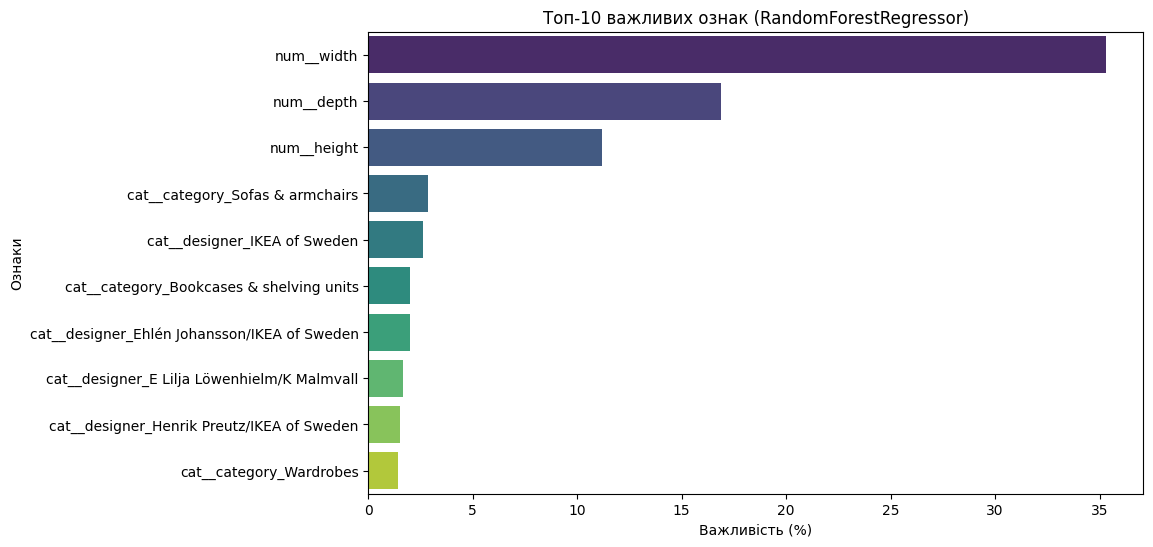

In [74]:
# Отримуємо імена ознак після трансформації
feature_names = preprocessor.get_feature_names_out()

# Отримуємо важливість ознак у відсотках
feature_importances = grid_search.best_estimator_.named_steps['regressor'].feature_importances_

# Перевіряємо довжини
print(f"Feature Names: {len(feature_names)}, Feature Importances: {len(feature_importances)}")

# Створюємо DataFrame (тільки якщо довжини збігаються)
feat_importance_df = pd.DataFrame({
    'Ознака': feature_names,
    'Важливість (%)': 100 * (feature_importances / np.sum(feature_importances))
}).sort_values(by='Важливість (%)', ascending=False)

# Вивід
top_features = feat_importance_df.head(10)
print(top_features)

# Візуалізація
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features['Важливість (%)'], y=top_features['Ознака'], palette='viridis')
plt.xlabel("Важливість (%)")
plt.ylabel("Ознаки")
plt.title("Топ-10 важливих ознак (RandomForestRegressor)")
plt.show()

In [75]:
#кросс-валідація з найкращими параметрами для RandomForestRegressor:
RandomForest_model = grid_search.best_estimator_
cv_scores2 = cross_val_score(grid_search.best_estimator_, X_train, Y_train, cv=5, scoring='r2')
print(f"Результати крос-валідації для {best_model_name}:\n", '-'*40)
print("R² для кожного розбиття:", cv_scores2)
print(f"Середнє R² крос-валідації: {cv_scores2.mean():.4f}")
print(f"Стандартне відхилення R²: {cv_scores2.std():.4f}")

Результати крос-валідації для Random Forest:
 ----------------------------------------
R² для кожного розбиття: [0.79056338 0.78008228 0.78382776 0.70709377 0.73419464]
Середнє R² крос-валідації: 0.7592
Стандартне відхилення R²: 0.0328


In [76]:
# Прогнозування та оцінка якості:
Y_pred = RandomForest_model.predict(X_test)

print('В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:\n', '-'*70)
print(f"Test R²: {r2_score(Y_test, Y_pred):.4f}")

mse = mean_squared_error(Y_test, Y_pred)
print(f"MSE: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:
 ----------------------------------------------------------------------
Test R²: 0.7810
MSE: 481481.5563
RMSE: 693.8887


**5с. Покращення параметрів для:**


*    RandomForestRegressor:

In [77]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'regressor__n_estimators': [10, 50, 100, 150, 200],
    'regressor__max_depth': [10, 20, 30, 40, 50],
    'regressor__max_features': ['sqrt', 'log2']
}

# Виконання GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [78]:
grid_search.fit(X_train, Y_train)
print("Найкращі параметри:", grid_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Найкращі параметри: {'regressor__max_depth': 50, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 200}


In [79]:
#кросс-валідація з найкращими параметрами для RandomForestRegressor:
RandomForest_model = grid_search.best_estimator_
cv_scores3 = cross_val_score(grid_search.best_estimator_, X_train, Y_train, cv=5, scoring='r2')
print(f"Результати крос-валідації для {best_model_name}:\n", '-'*40)
print("R² для кожного розбиття:", cv_scores3)
print(f"Середнє R² крос-валідації: {cv_scores3.mean():.4f}")
print(f"Стандартне відхилення R²: {cv_scores3.std():.4f}")

Результати крос-валідації для Random Forest:
 ----------------------------------------
R² для кожного розбиття: [0.79684678 0.78885959 0.79289458 0.7233182  0.75529992]
Середнє R² крос-валідації: 0.7714
Стандартне відхилення R²: 0.0282


In [81]:
# Прогнозування та оцінка якості:
Y_pred = RandomForest_model.predict(X_test)

print('В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:\n', '-'*70)
print(f"Test R²: {r2_score(Y_test, Y_pred):.4f}")

mse = mean_squared_error(Y_test, Y_pred)
print(f"MSE: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

В результаті відпрацювання моделі зі знайденими найкращими гіперпараметрами:
 ----------------------------------------------------------------------
Test R²: 0.7979
MSE: 444254.6663
RMSE: 666.5243


**5d. Виконання крос-валідації з дефолтною моделлю**


In [82]:
# Створення пайплайна з RandomForestRegressor
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

pipeline.fit(X_train, Y_train)# Тренуємо модель на тренувальних даних

Y_pred = pipeline.predict(X_test)# Перевіряємо результати на тестових даних

In [83]:
# Виконання крос-валідації з RandomForestRegressor
cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='r2')

# Виведення результатів крос-валідації
print("R² для кожного розбиття крос-валідації:", cv_scores)
print(f"Середнє R² крос-валідації: {cv_scores.mean():.4f}")
print(f"Стандартне відхилення R²: {cv_scores.std():.4f}")

R² для кожного розбиття крос-валідації: [0.77754126 0.78142753 0.78279706 0.71960494 0.76977716]
Середнє R² крос-валідації: 0.7662
Стандартне відхилення R²: 0.0237


In [84]:
# Виведення результатів
print(f"R² на тестових даних: {r2_score(Y_test, Y_pred):.4f}")
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse**0.5
print(f"RMSE на тестових даних: {rmse:.4f}")
print(f"MSE на тестових даних: {mse:.4f}")

R² на тестових даних: 0.8302
RMSE на тестових даних: 611.0288
MSE на тестових даних: 373356.2007


In [85]:
grid_search

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['depth',
                                                                          'width',
                                                                          'height']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['category',
                                                                          'designer',
                                                                          'other_colors'])])),
                                       ('regressor',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [10, 20, 30, 40, 50],
                         'regressor__max_features': ['sqrt', 'log2'],
                         'regressor__n_estimators': [10, 50, 100, 150, 200]},
             scoring='neg_mean_squared_error', verbose=2)

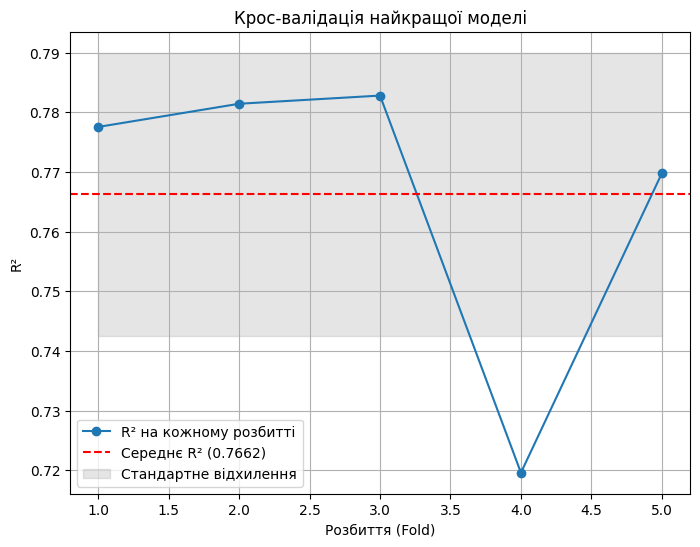

In [86]:
# Візуалізація результатів крос-валідації
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', label="R² на кожному розбитті")
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f"Середнє R² ({cv_scores.mean():.4f})")
plt.fill_between(range(1, len(cv_scores) + 1),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 color='gray', alpha=0.2, label="Стандартне відхилення")
plt.title("Крос-валідація найкращої моделі")
plt.xlabel("Розбиття (Fold)")
plt.ylabel("R²")
plt.legend()
plt.grid()
plt.show()

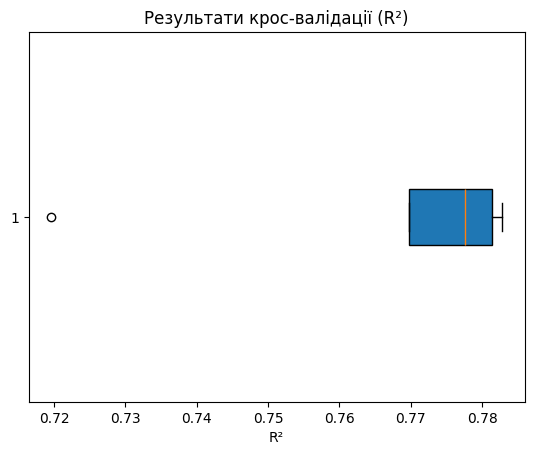

In [87]:
plt.boxplot(cv_scores, vert=False, patch_artist=True)
plt.title("Результати крос-валідації (R²)")
plt.xlabel("R²")
plt.show()